# DESI DR1 LSS catalogue diagnostics

Interactive, reproducible diagnostics for the local DESI DR1 LSS research bundle. This notebook is intentionally descriptive: it does **not** estimate clustering, a density field, or voids, because those require DESI random catalogues and survey-mask treatment.

Run cells from top to bottom. The analysis scans the Parquet catalogue once, creates deterministic outputs in `figures/`, and displays the main results here.

In [1]:
!git clone --branch research-analysis-suite-v1 https://github.com/Biswajit1999/NASADIYA-LIGHTCONE.git
%cd NASADIYA-LIGHTCONE
!pip -q install pyarrow pandas matplotlib

Cloning into 'NASADIYA-LIGHTCONE'...
remote: Enumerating objects: 4691, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 4691 (delta 39), reused 33 (delta 33), pack-reused 4597 (from 4)
Receiving objects: 100% (4691/4691), 487.66 MiB | 16.75 MiB/s, done.
Resolving deltas: 100% (202/202), done.
Updating files: 100% (4329/4329), done.
/content/NASADIYA-LIGHTCONE


In [6]:
from pathlib import Path
import shutil

matches = list(Path("/content").rglob("desi_dr1_lss_research_bundle*.parquet"))

print("Found:")
for file in matches:
    print(file, f"({file.stat().st_size / 1024**2:.1f} MB)")

assert matches, "Dataset was not found anywhere under /content."

source = max(matches, key=lambda p: p.stat().st_mtime)

DATA_DIR = Path("/content/NASADIYA-LIGHTCONE/data/research")
DATA_DIR.mkdir(parents=True, exist_ok=True)

target = DATA_DIR / "desi_dr1_lss_research_bundle.parquet"

if source.resolve() != target.resolve():
    shutil.move(str(source), str(target))

print(f"\nReady: {target}")
print(f"Size: {target.stat().st_size / 1024**2:.1f} MB")

Found:
/content/NASADIYA-LIGHTCONE/desi_dr1_lss_research_bundle.parquet (185.1 MB)
/content/NASADIYA-LIGHTCONE/desi_dr1_lss_research_bundle (1).parquet (185.1 MB)

Ready: /content/NASADIYA-LIGHTCONE/data/research/desi_dr1_lss_research_bundle.parquet
Size: 185.1 MB


In [7]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path("/content/NASADIYA-LIGHTCONE")

sys.path.insert(0, str(ROOT / "scripts"))
from analyze_desi_catalogue import (
    scan_catalogue,
    write_statistics_csv,
    plot_tracer_fractions,
    plot_cartesian_slice,
)

INPUT = ROOT / "data" / "research" / "desi_dr1_lss_research_bundle.parquet"
OUTPUT_DIR = ROOT / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)

assert INPUT.exists(), f"Research bundle not found: {INPUT}"

print(f"Repository root: {ROOT}")
print(f"Input bundle: {INPUT.name}")

Repository root: /content/NASADIYA-LIGHTCONE
Input bundle: desi_dr1_lss_research_bundle.parquet


In [8]:
# Analysis controls — safe to adjust and rerun.
SLICE_Z_MPC = 0.0
SLICE_THICKNESS_MPC = 300.0
SLICE_RENDER_ROWS = 100_000
Z_MAX = 3.6
Z_BINS = 90
DPI = 240

In [9]:
slice_frame, summary = scan_catalogue(
    INPUT,
    slice_z_mpc=SLICE_Z_MPC,
    slice_thickness_mpc=SLICE_THICKNESS_MPC,
    slice_render_rows=SLICE_RENDER_ROWS,
    z_max=Z_MAX,
    z_bins=Z_BINS,
)

statistics_path = OUTPUT_DIR / 'desi_dr1_tracer_statistics.csv'
composition_path = OUTPUT_DIR / 'desi_dr1_tracer_composition.png'
slice_path = OUTPUT_DIR / 'desi_dr1_cartesian_slice.png'

write_statistics_csv(summary, statistics_path)
plot_tracer_fractions(summary, composition_path, DPI)
plot_cartesian_slice(slice_frame, summary, slice_path, DPI)

print(f"Rows scanned: {summary['input_rows']:,}")
print(f"Deterministic slice rows rendered: {summary['cartesian_slice']['rendered_rows']:,}")
print(f"Saved: {statistics_path.relative_to(ROOT)}")
print(f"Saved: {composition_path.relative_to(ROOT)}")
print(f"Saved: {slice_path.relative_to(ROOT)}")

Rows scanned: 6,093,818
Deterministic slice rows rendered: 100,000
Saved: figures/desi_dr1_tracer_statistics.csv
Saved: figures/desi_dr1_tracer_composition.png
Saved: figures/desi_dr1_cartesian_slice.png


## Per-tracer catalogue summary

The coordinate residual compares Cartesian radius, $\sqrt{x^2+y^2+z^2}$, against the stored comoving distance. It is a coordinate-consistency diagnostic, not a cosmology fit.

In [10]:
stats = (pd.DataFrame.from_dict(summary['tracer_statistics'], orient='index')
           .rename_axis('tracer')
           .reset_index())
stats['rows'] = stats['rows'].astype('int64')
display(stats.style.format({
    'rows': '{:,.0f}',
    'redshift_p16': '{:.4f}', 'redshift_median': '{:.4f}', 'redshift_p84': '{:.4f}',
    'coordinate_radius_minus_chi_mean_mpc': '{:.6g}',
    'coordinate_radius_minus_chi_rms_mpc': '{:.6g}',
    'coordinate_radius_minus_chi_mean_abs_mpc': '{:.6g}',
    'coordinate_radius_minus_chi_max_abs_mpc': '{:.6g}',
}))

,tracer,rows,redshift_p16,redshift_median,redshift_p84,coordinate_radius_minus_chi_mean_mpc,coordinate_radius_minus_chi_rms_mpc,coordinate_radius_minus_chi_mean_abs_mpc,coordinate_radius_minus_chi_max_abs_mpc
0,BGS,"300,017",0.2143,0.3142,0.3754,-2.7244e-08,4.10476e-05,3.27037e-05,0.000140495
1,ELG,"2,432,027",0.9241,1.1601,1.4237,6.26947e-08,0.000122144,9.68011e-05,0.000487258
2,LRG,"2,138,604",0.5463,0.7532,0.9210,2.93876e-08,8.68793e-05,7.01243e-05,0.000292037
3,QSO,"1,223,170",1.1840,1.7417,2.4385,1.56244e-07,0.000163909,0.000131391,0.000574605


## Tracer composition with redshift

This is the fraction of observed rows in each redshift bin. It is not completeness-corrected.

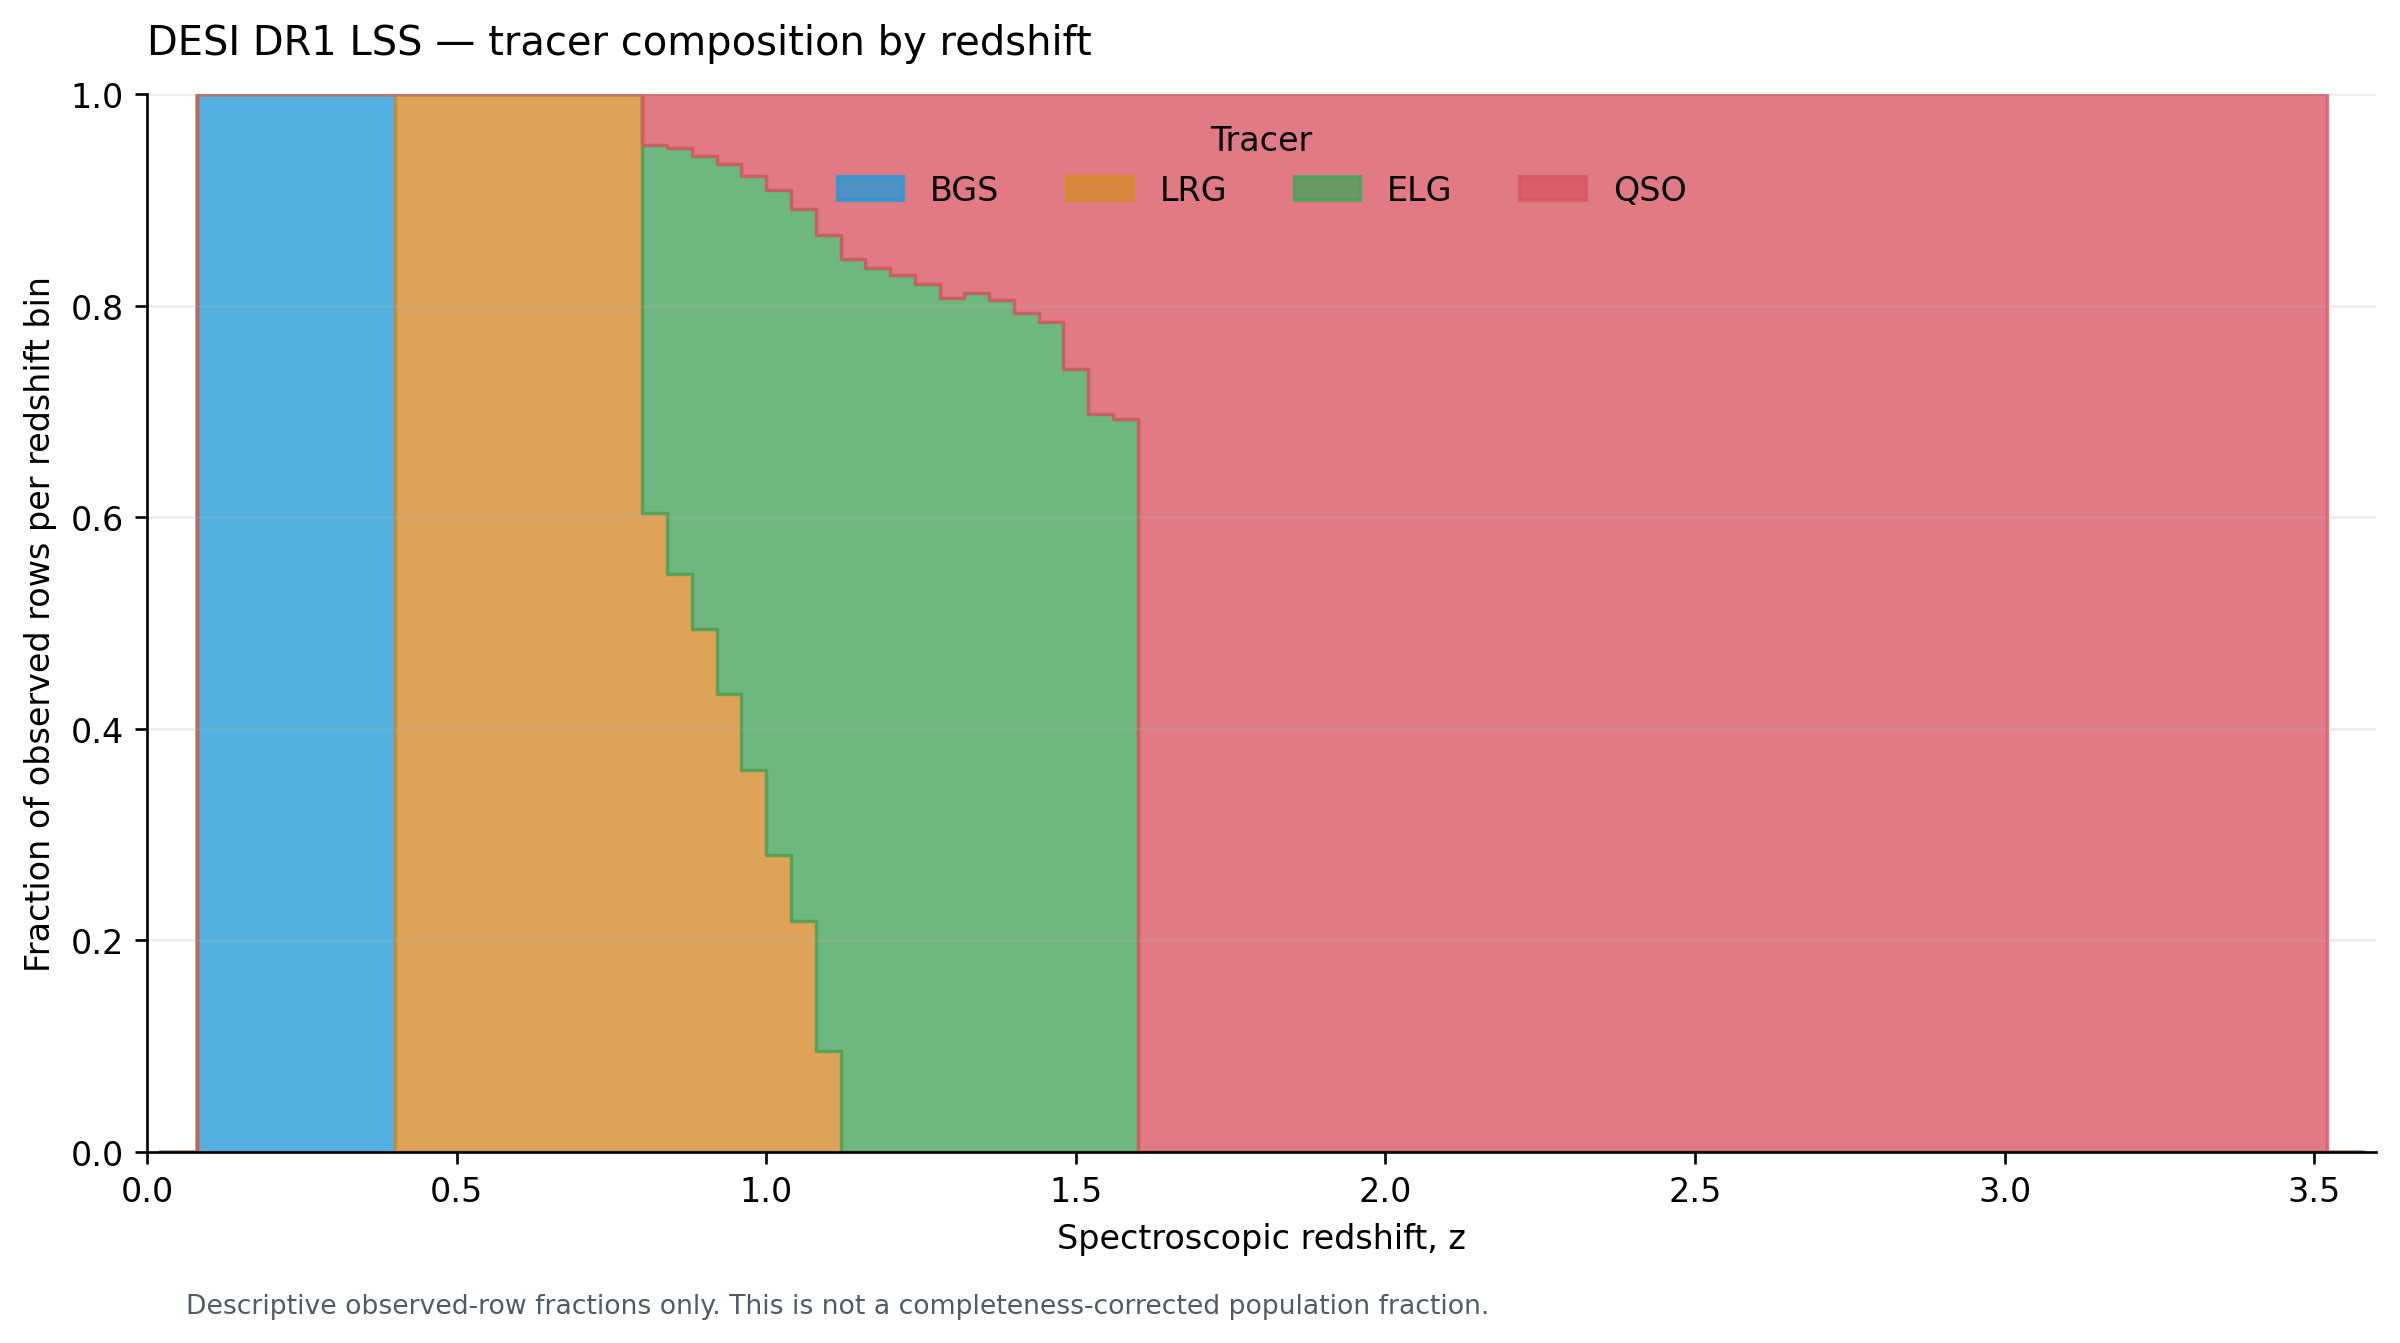

In [11]:
display(Image(filename=str(composition_path)))

## Deterministic Cartesian slice

The plotted points are selected using the exact globally lowest stable object-ID hashes within the requested slice, so the same settings reproduce the same rendered sample. This is an observed-galaxy map, not a reconstructed density field.

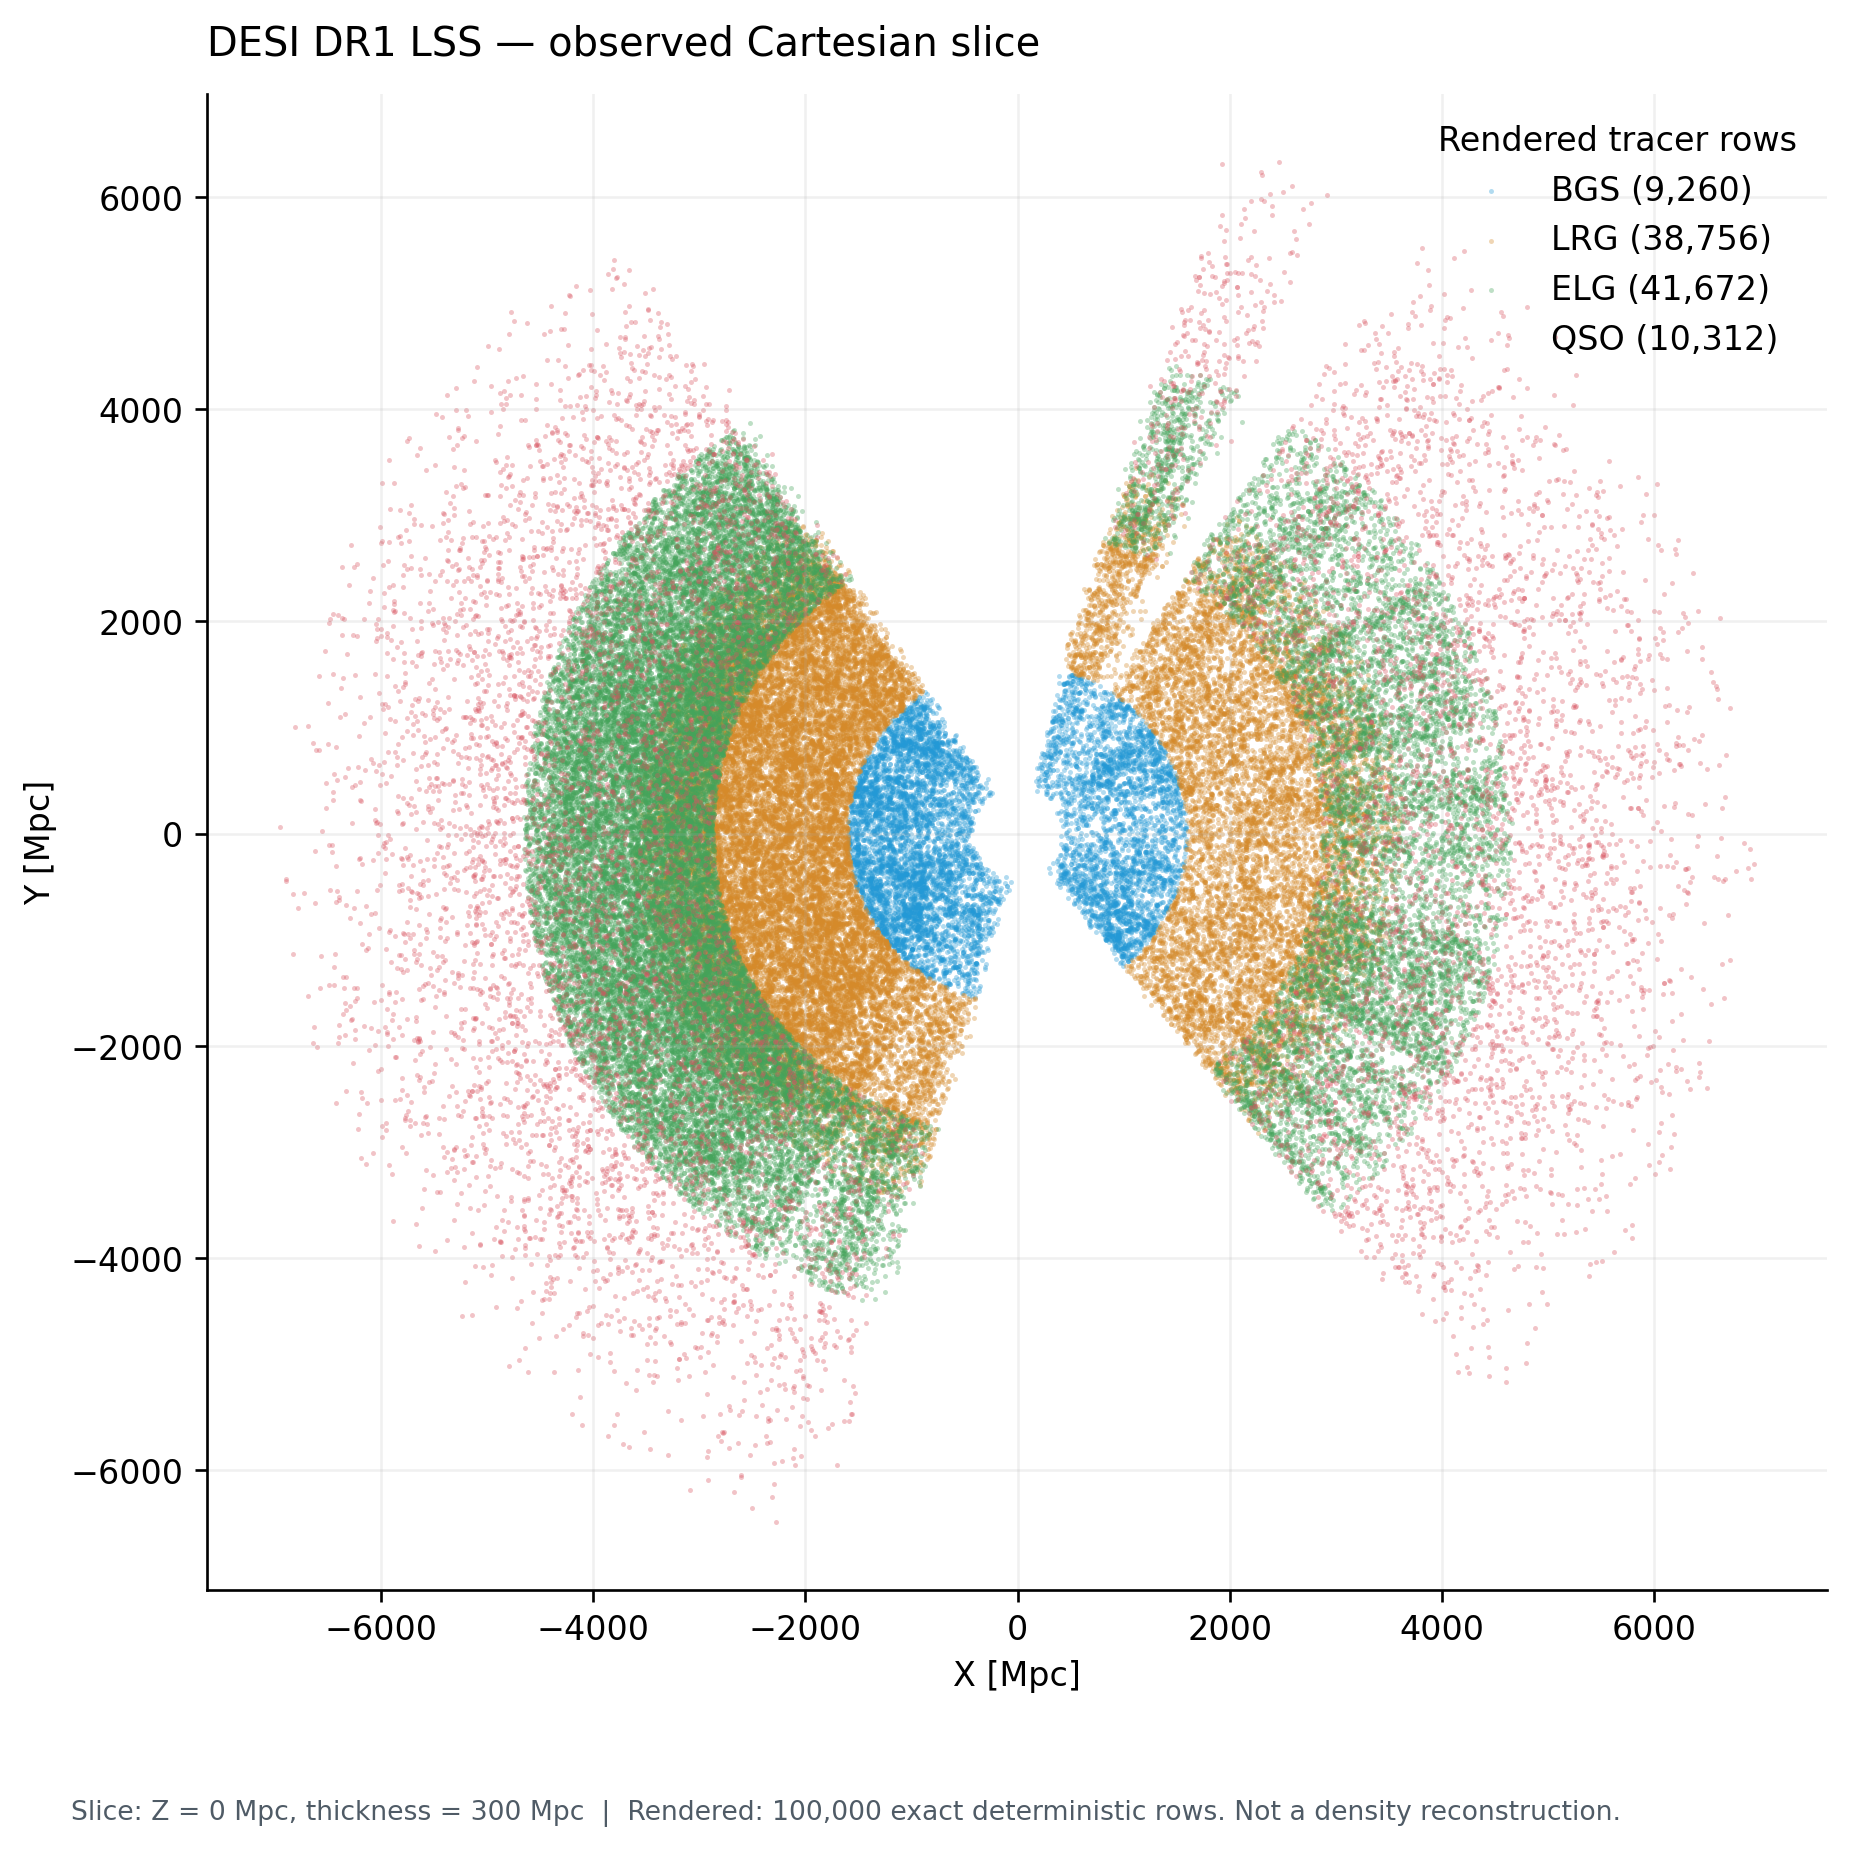

,object_id,tracer,x_mpc,y_mpc,z_mpc,redshift
0,desi-dr1:BGS:39627357140555224,BGS,369.671570,189.687759,-134.038040,0.100952
1,desi-dr1:BGS:39627374861488255,BGS,273.225494,375.307648,-145.224655,0.112805
2,desi-dr1:BGS:39627397456204716,BGS,460.231628,164.293991,-142.161453,0.118187
3,desi-dr1:BGS:39627421271458021,BGS,281.527557,373.925446,-126.933510,0.112460
4,desi-dr1:BGS:39627432998734396,BGS,267.018188,397.620911,-125.985069,0.114915
5,desi-dr1:BGS:39627433007122216,BGS,295.042603,447.696991,-142.121399,0.129165
6,desi-dr1:BGS:39627438547799187,BGS,422.840332,327.300812,-138.890457,0.128628
7,desi-dr1:BGS:39627444134615157,BGS,477.306091,185.829834,-131.088394,0.122925
8,desi-dr1:BGS:39627455870274417,BGS,476.384125,189.260544,-126.114304,0.122727
9,desi-dr1:BGS:39627462031710800,BGS,413.885193,341.100677,-127.639885,0.128352


In [12]:
display(Image(filename=str(slice_path)))
display(slice_frame.head(10))

## Scientific boundary

To measure clustering, correlation functions, overdensity, or void candidates rigorously, add the tracer-specific DESI random catalogues, angular completeness/mask information, and a validated estimator.

In [13]:
from google.colab import files
from pathlib import Path

FIGURES = Path("/content/NASADIYA-LIGHTCONE/figures")

for file in sorted(FIGURES.iterdir()):
    print(file.name, f"{file.stat().st_size / 1024**2:.2f} MB")

files.download(str(FIGURES / "desi_dr1_tracer_statistics.csv"))
files.download(str(FIGURES / "desi_dr1_tracer_composition.png"))
files.download(str(FIGURES / "desi_dr1_cartesian_slice.png"))
files.download(str(FIGURES / "desi_dr1_catalogue_diagnostics.json"))

.gitkeep 0.00 MB
desi_dr1_cartesian_slice.png 1.42 MB
desi_dr1_lss_3d_research_view.png 0.92 MB
desi_dr1_lss_redshift_summary.png 0.10 MB
desi_dr1_lss_research_summary.json 0.01 MB
desi_dr1_lss_sky_footprint.png 0.41 MB
desi_dr1_tracer_composition.png 0.11 MB
desi_dr1_tracer_statistics.csv 0.00 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/NASADIYA-LIGHTCONE/figures/desi_dr1_catalogue_diagnostics.json